In [101]:
#Imports

In [102]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [103]:
#Load the dataset and clean column names

In [104]:
df = pd.read_csv("student_performance_updated_1000.csv")
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Columns:
['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']

First 5 rows:
   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High 

In [105]:
#Drop coloumn

In [106]:
df = df.drop(columns=["StudentID", "Name", "Study Hours", "Attendance (%)"], errors="ignore")

print("Columns after dropping unnecessary fields:")
print(df.columns.tolist())

Columns after dropping unnecessary fields:
['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Online Classes Taken']


In [107]:
#Handle missing value

In [108]:
numeric_cols = ["AttendanceRate", "StudyHoursPerWeek", "PreviousGrade",
                "ExtracurricularActivities", "FinalGrade"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].mean())

print("Missing values in numeric columns:")
print(df[numeric_cols].isna().sum())

Missing values in numeric columns:
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
FinalGrade                   0
dtype: int64


In [109]:
#Handle missing values in categorical columns

In [110]:
categorical_cols = ["Gender", "ParentalSupport", "Online Classes Taken"]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(["nan", "None", ""], np.nan)
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values in categorical columns:")
print(df[categorical_cols].isna().sum())

Missing values in categorical columns:
Gender                  0
ParentalSupport         0
Online Classes Taken    0
dtype: int64


In [111]:
#Inspect real category values

In [112]:
print("Unique values in Gender:")
print(df["Gender"].dropna().unique())

print("\nUnique values in ParentalSupport:")
print(df["ParentalSupport"].dropna().unique())

print("\nUnique values in Online Classes Taken:")
print(df["Online Classes Taken"].dropna().unique())

Unique values in Gender:
['Male' 'Female']

Unique values in ParentalSupport:
['High' 'Medium' 'Low']

Unique values in Online Classes Taken:
['False' 'True']


In [ ]:
#Encode categorical variables

In [113]:
# Gender: Male = 1, Female = 0
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# ParentalSupport: Low = 1, Medium = 2, High = 3
df["ParentalSupport"] = df["ParentalSupport"].map({"Low": 1, "Medium": 2, "High": 3})

# Online Classes Taken: False = 0, True = 1
df["Online Classes Taken"] = df["Online Classes Taken"].map({"False": 0, "True": 1, False: 0, True: 1})

print("Encoded columns preview:")
print(df[["Gender", "ParentalSupport", "Online Classes Taken"]].head())

print("\nMissing values after encoding:")
print(df[["Gender", "ParentalSupport", "Online Classes Taken"]].isna().sum())

Encoded columns preview:
   Gender  ParentalSupport  Online Classes Taken
0       1                3                     0
1       0                2                     1
2       1                1                     0
3       1                3                     0
4       0                2                     1

Missing values after encoding:
Gender                  0
ParentalSupport         0
Online Classes Taken    0
dtype: int64


In [ ]:
#Remove outliers

In [114]:
print("Shape before outlier removal:", df.shape)

for col in ["AttendanceRate", "StudyHoursPerWeek", "PreviousGrade", "FinalGrade"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after outlier removal:", df.shape)

Shape before outlier removal: (1000, 8)
Shape after outlier removal: (1000, 8)


In [ ]:
#Define x and y 

In [115]:
# Define independent and dependent variables

X = df.drop("FinalGrade", axis=1)
y = df["FinalGrade"]

print("X columns:")
print(X.columns.tolist())

print("\ny variable:")
print(y.name)

X columns:
['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'Online Classes Taken']

y variable:
FinalGrade


In [ ]:
#Final check before splitting

In [116]:
print("Missing values in X:")
print(X.isna().sum())

print("\nMissing values in y:")
print(y.isna().sum())

Missing values in X:
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
Online Classes Taken         0
dtype: int64

Missing values in y:
0


In [ ]:
#Split dataset

In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 7)
X_test shape: (200, 7)
y_train shape: (800,)
y_test shape: (200,)


In [ ]:
#Feature scaling

In [118]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing DONE successfully.")

Preprocessing DONE successfully.


In [ ]:
#classification the dataset

In [130]:
# ==============================
# CREATE CLASSIFICATION TARGET
# ==============================

def categorize_grade(grade):
    if grade < 70:
        return "Low"
    elif grade <= 85:
        return "Medium"
    else:
        return "High"

df['GradeCategory'] = df['FinalGrade'].apply(categorize_grade)

print(df[['FinalGrade', 'GradeCategory']].head())

   FinalGrade GradeCategory
0        80.0        Medium
1        87.0          High
2        68.0           Low
3        92.0          High
4        85.0        Medium


In [ ]:
#Classification target

In [133]:
def categorize_grade(grade):
    if grade < 70:
        return "Low"
    elif grade <= 85:
        return "Medium"
    else:
        return "High"

df['GradeCategory'] = df['FinalGrade'].apply(categorize_grade)

In [ ]:
#Define x and y 

In [134]:
X = df.drop(columns=["FinalGrade", "GradeCategory"])
y = df["GradeCategory"]

In [ ]:
#Split and Scaling

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#logistic regession

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.425
Confusion Matrix:
 [[ 8  0 67]
 [ 4  0 36]
 [ 8  0 77]]
Classification Report:
               precision    recall  f1-score   support

        High       0.40      0.11      0.17        75
         Low       0.00      0.00      0.00        40
      Medium       0.43      0.91      0.58        85

    accuracy                           0.42       200
   macro avg       0.28      0.34      0.25       200
weighted avg       0.33      0.42      0.31       200



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
#KNN

In [139]:
# ==============================
# K-NEAREST NEIGHBORS (KNN)
# ==============================

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Results:
Accuracy: 0.355
Confusion Matrix:
 [[34  6 35]
 [21  5 14]
 [41 12 32]]
Classification Report:
               precision    recall  f1-score   support

        High       0.35      0.45      0.40        75
         Low       0.22      0.12      0.16        40
      Medium       0.40      0.38      0.39        85

    accuracy                           0.35       200
   macro avg       0.32      0.32      0.31       200
weighted avg       0.34      0.35      0.34       200



In [ ]:
#Naive Bayes

In [141]:
print("Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb, zero_division=0))

Naive Bayes Results:
Accuracy: 0.395
Confusion Matrix:
 [[ 6  0 69]
 [ 5  0 35]
 [12  0 73]]
Classification Report:
               precision    recall  f1-score   support

        High       0.26      0.08      0.12        75
         Low       0.00      0.00      0.00        40
      Medium       0.41      0.86      0.56        85

    accuracy                           0.40       200
   macro avg       0.22      0.31      0.23       200
weighted avg       0.27      0.40      0.28       200



In [ ]:
Decision Tree

In [143]:
# ==============================
# DECISION TREE
# ==============================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Results:
Accuracy: 0.355
Confusion Matrix:
 [[20 10 45]
 [10 10 20]
 [25 19 41]]
Classification Report:
               precision    recall  f1-score   support

        High       0.36      0.27      0.31        75
         Low       0.26      0.25      0.25        40
      Medium       0.39      0.48      0.43        85

    accuracy                           0.35       200
   macro avg       0.34      0.33      0.33       200
weighted avg       0.35      0.35      0.35       200



In [ ]:
#Spport Vector Machine

In [145]:
print("SVM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm, zero_division=0))

SVM Results:
Accuracy: 0.42
Confusion Matrix:
 [[14  0 61]
 [ 5  0 35]
 [15  0 70]]
Classification Report:
               precision    recall  f1-score   support

        High       0.41      0.19      0.26        75
         Low       0.00      0.00      0.00        40
      Medium       0.42      0.82      0.56        85

    accuracy                           0.42       200
   macro avg       0.28      0.34      0.27       200
weighted avg       0.33      0.42      0.33       200



In [ ]:
#Random Forest

In [146]:
# ==============================
# RANDOM FOREST
# ==============================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.37
Confusion Matrix:
 [[21  1 53]
 [16  4 20]
 [31  5 49]]
Classification Report:
               precision    recall  f1-score   support

        High       0.31      0.28      0.29        75
         Low       0.40      0.10      0.16        40
      Medium       0.40      0.58      0.47        85

    accuracy                           0.37       200
   macro avg       0.37      0.32      0.31       200
weighted avg       0.37      0.37      0.34       200



In [ ]:
#CLASSIFICATION MODEL COMPARISON

In [147]:
# ==============================
# CLASSIFICATION MODEL COMPARISON
# ==============================

results_clf = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Naive Bayes",
        "Decision Tree",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results_clf)

                 Model  Accuracy
0  Logistic Regression     0.425
1                  KNN     0.355
2          Naive Bayes     0.395
3        Decision Tree     0.355
4                  SVM     0.420
5        Random Forest     0.370


In [ ]:
#Picking the best classifier

In [148]:
best_clf = results_clf.loc[results_clf["Accuracy"].idxmax()]
print("Best Classifier:")
print(best_clf)

Best Classifier:
Model       Logistic Regression
Accuracy                  0.425
Name: 0, dtype: object


In [ ]:
#Counting the number of elements 

In [149]:
print("Number of elements in each category:")
print(df["GradeCategory"].value_counts())

Number of elements in each category:
GradeCategory
Medium    453
High      364
Low       183
Name: count, dtype: int64


In [ ]:
#classicification model results 

In [151]:
summary_table["Accuracy"] = summary_table["Accuracy"].round(3)
print(summary_table)

                 Model                            Confusion Matrix  \
0  Logistic Regression        [[8, 0, 67], [4, 0, 36], [8, 0, 77]]   
1  K-Nearest Neighbors    [[34, 6, 35], [21, 5, 14], [41, 12, 32]]   
2          Naive Bayes       [[6, 0, 69], [5, 0, 35], [12, 0, 73]]   
3        Decision Tree  [[20, 10, 45], [10, 10, 20], [25, 19, 41]]   
4                  SVM      [[14, 0, 61], [5, 0, 35], [15, 0, 70]]   
5        Random Forest     [[21, 1, 53], [16, 4, 20], [31, 5, 49]]   

   Errors (FP + FN)  Accuracy  
0               115     0.425  
1               129     0.355  
2               121     0.395  
3               129     0.355  
4               116     0.420  
5               126     0.370  


In [ ]:
#finding the numbers

In [153]:
# ==============================
# NUMBER OF ELEMENTS BASED ON BEST CLASSIFIER
# ==============================

counts = pd.Series(y_pred_log).value_counts()

# Ensure all categories appear
counts = counts.reindex(["Low", "Medium", "High"], fill_value=0)

print("Number of elements predicted by best classifier (Logistic Regression):")
print(counts)

Number of elements predicted by best classifier (Logistic Regression):
Low         0
Medium    180
High       20
Name: count, dtype: int64


In [ ]:
# CLUSTER ANALYSIS

In [155]:
# Select features
features = [
    "AttendanceRate",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "ExtracurricularActivities"
]

X_cluster = df[features]

In [ ]:
#Scaling 

In [156]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
#Elbow method

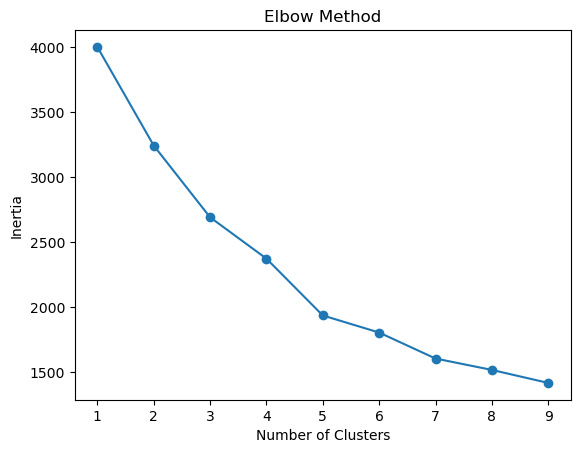

In [158]:
# Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
#Applying the Km=Means

In [159]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
1    369
2    352
0    279
Name: count, dtype: int64


In [ ]:
# Visualization

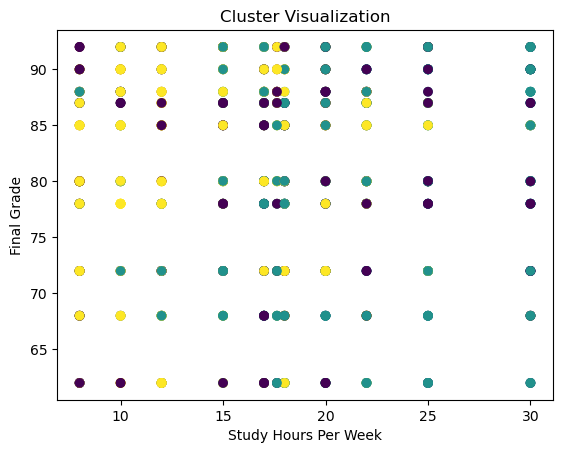

In [160]:

plt.scatter(df["StudyHoursPerWeek"], df["FinalGrade"], c=df["Cluster"])
plt.xlabel("Study Hours Per Week")
plt.ylabel("Final Grade")
plt.title("Cluster Visualization")
plt.show()

In [ ]:
#CLUSTER SUMMARY

In [161]:


cluster_summary = df.groupby("Cluster")[[
    "AttendanceRate",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "ExtracurricularActivities",
    "FinalGrade"
]].mean()

print(cluster_summary)

         AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
Cluster                                                     
0             85.014785          17.191605      64.103943   
1             85.494947          20.489753      82.359296   
2             85.919478          14.981106      83.304486   

         ExtracurricularActivities  FinalGrade  
Cluster                                         
0                         1.323603   80.187571  
1                         2.352966   79.662720  
2                         0.803541   80.290717  


In [136]:
#Linear regression

In [119]:
# ==============================
# LINEAR REGRESSION
# ==============================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("MSE:", mse_lr)
print("R2:", r2_lr)

Linear Regression Results:
MSE: 91.18712602856138
R2: -0.015510891339039823


In [ ]:
#POLYNOMIAL REGRESSION

In [120]:
# ==============================
# POLYNOMIAL REGRESSION (Degree 2)
# ==============================

from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results:")
print("MSE:", mse_poly)
print("R2:", r2_poly)

Polynomial Regression Results:
MSE: 93.52947022535423
R2: -0.04159654779851518


In [ ]:
#Ridge Regression

In [121]:
# ==============================
# RIDGE REGRESSION
# ==============================

from sklearn.linear_model import Ridge

# Create model (alpha = strength of regularization)
ridge_model = Ridge(alpha=1.0)

# Train
ridge_model.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results:")
print("MSE:", mse_ridge)
print("R2:", r2_ridge)

Ridge Regression Results:
MSE: 91.18448194380726
R2: -0.015481445330788546


In [ ]:
#Lasso Regression

In [122]:
# ==============================
# LASSO REGRESSION
# ==============================

from sklearn.linear_model import Lasso

# Create model
lasso_model = Lasso(alpha=0.1)

# Train
lasso_model.fit(X_train, y_train)

# Predict
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results:")
print("MSE:", mse_lasso)
print("R2:", r2_lasso)

Lasso Regression Results:
MSE: 90.84776466412599
R2: -0.011731573175466137


In [ ]:
#Elastic net regression

In [123]:
# ==============================
# ELASTIC NET REGRESSION
# ==============================

from sklearn.linear_model import ElasticNet

# Create model
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

# Train
elastic_model.fit(X_train, y_train)

# Predict
y_pred_elastic = elastic_model.predict(X_test)

# Evaluate
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)

print("Elastic Net Results:")
print("MSE:", mse_elastic)
print("R2:", r2_elastic)

Elastic Net Results:
MSE: 90.91076087738806
R2: -0.012433134278079683


In [ ]:
#Compare models

In [124]:
# ==============================
# MODEL COMPARISON
# ==============================

import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression", "Ridge", "Lasso", "Elastic Net"],
    "MSE": [mse_lr, mse_poly, mse_ridge, mse_lasso, mse_elastic],
    "R2": [r2_lr, r2_poly, r2_ridge, r2_lasso, r2_elastic]
})

print(results)

                   Model        MSE        R2
0      Linear Regression  91.187126 -0.015511
1  Polynomial Regression  93.529470 -0.041597
2                  Ridge  91.184482 -0.015481
3                  Lasso  90.847765 -0.011732
4            Elastic Net  90.910761 -0.012433


In [ ]:
#Select best model

In [125]:
best_model = results.loc[results["R2"].idxmax()]
print("\nBest Model:")
print(best_model)


Best Model:
Model        Lasso
MSE      90.847765
R2       -0.011732
Name: 3, dtype: object


In [ ]:
#Get equation values

In [126]:
# ==============================
# GET LASSO EQUATION
# ==============================

coefficients = lasso_model.coef_
intercept = lasso_model.intercept_

print("Intercept:", intercept)

print("\nCoefficients:")
for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef}")

Intercept: 80.03105729166667

Coefficients:
Gender: -0.5340905157994607
AttendanceRate: -0.0
StudyHoursPerWeek: 0.2990870553904383
PreviousGrade: 0.0
ExtracurricularActivities: -0.05447701035450402
ParentalSupport: -0.24133697843921617
Online Classes Taken: 0.17753946220540337


In [ ]:
#ACTUAL VS PREDICTED SCATTER PLOT

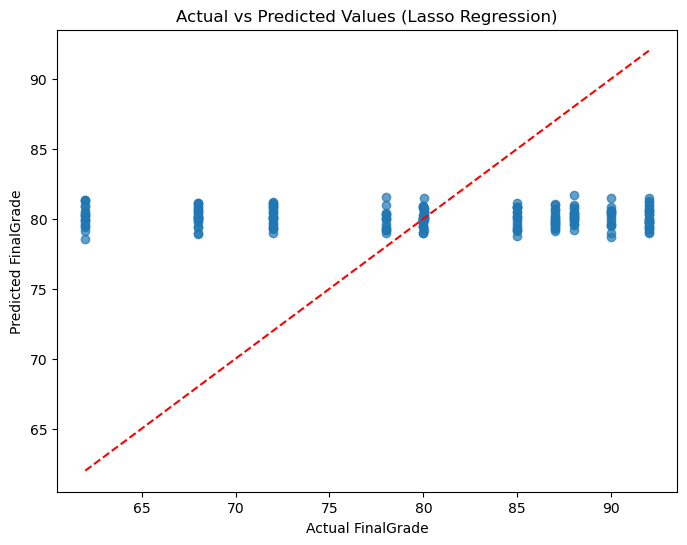

In [127]:
# ==============================
# ACTUAL VS PREDICTED SCATTER PLOT
# ==============================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.7)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_lasso.min())
max_val = max(y_test.max(), y_pred_lasso.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual FinalGrade")
plt.ylabel("Predicted FinalGrade")
plt.title("Actual vs Predicted Values (Lasso Regression)")
plt.show()

In [ ]:
#Print best model clearly

In [128]:
# ==============================
# BEST MODEL SUMMARY
# ==============================
print("Best Model: Lasso Regression")
print("Intercept:", lasso_model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, lasso_model.coef_):
    print(f"{feature}: {coef}")

Best Model: Lasso Regression
Intercept: 80.03105729166667

Coefficients:
Gender: -0.5340905157994607
AttendanceRate: -0.0
StudyHoursPerWeek: 0.2990870553904383
PreviousGrade: 0.0
ExtracurricularActivities: -0.05447701035450402
ParentalSupport: -0.24133697843921617
Online Classes Taken: 0.17753946220540337


In [ ]:
#Select 5 random rows for manual substitution

In [129]:
# ==============================
# SELECT 5 RANDOM ROWS FOR MANUAL SUBSTITUTION
# ==============================
sample_5 = df.sample(5, random_state=42)[[
    "Gender",
    "StudyHoursPerWeek",
    "ExtracurricularActivities",
    "ParentalSupport",
    "Online Classes Taken",
    "FinalGrade"
]]

print(sample_5)

     Gender  StudyHoursPerWeek  ExtracurricularActivities  ParentalSupport  \
521       0               10.0                        0.0                1   
737       0               10.0                        1.0                3   
740       0               22.0                        1.0                1   
660       1               17.0                        1.0                3   
411       0               20.0                        2.0                1   

     Online Classes Taken  FinalGrade  
521                     1        72.0  
737                     0        62.0  
740                     1        62.0  
660                     1        80.0  
411                     0        85.0  
